# Gallery — what the samples actually look like

The metric tables say these ensembles are **over-confident**: the spread is a fraction of
the error. This notebook is for seeing that rather than reading it — a collapsed cloud and
a well-spread one give very different pictures, and a reconstruction can score respectably
while being visibly wrong in a way no scalar reports.

Four views, each with its knobs at the top of its cell:

1. **One instance in depth** — truth, ensemble mean, error, uncertainty, individual samples
2. **Methods side by side** — the same instance under every method and N
3. **Several instances** — is the behaviour typical or cherry-picked?
4. **Observation space** — does the reconstruction reproduce the data?

**Colour follows the physics.** Vorticity (navier-stokes) is signed, so it gets a diverging
map centred on zero; permittivity and intensity are positive, so they get a single-hue
sequential one. Error panels are always diverging and symmetric about zero. Panels showing
the *same* quantity share one colour scale, so they can be compared by eye — that is the
whole point of a gallery, and it is lost the moment each panel is normalised separately.

In [1]:
import sys, pathlib
ROOT = pathlib.Path('/mnt/home/gandry/kps/InverseBench')
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt, numpy as np, torch
from mpl_toolkits.axes_grid1 import make_axes_locatable
import report_metrics as rm

plt.rcParams.update({'figure.dpi': 110, 'font.size': 8.5, 'axes.titlesize': 8.5})

RUNS = {}                      # (problem, algo, run) -> sorted list of result files
for problem, algo, run, files in rm.runs(pattern='gen*'):
    RUNS[(problem, algo, run)] = files
for k, v in RUNS.items():
    print(f'{k[0]:<14}{k[1]:<6}{k[2]:<12}{len(v):>5} ids')

navier-stokes KPSH  gen_N128       10 ids
navier-stokes KPSH  gen_N256       10 ids
navier-stokes KPSH  gen_N512       10 ids
navier-stokes KPSH  gen_N64        10 ids
inv-scatter   KPSG  gen           100 ids
inv-scatter   KPSH  gen_N128      100 ids
inv-scatter   KPSH  gen_N256      100 ids
inv-scatter   KPSH  gen_N512      100 ids
inv-scatter   KPSH  gen_N64       100 ids
blackhole     KPSG  gen           100 ids
blackhole     KPSH  gen_N128      100 ids
blackhole     KPSH  gen_N256      100 ids
blackhole     KPSH  gen_N512      100 ids
blackhole     KPSH  gen_N64       100 ids


In [2]:
def load(problem, algo, run, i):
    r"""One saved ensemble as (samples, truth), both (..., C, H, W) and unnormalised."""
    d = torch.load(RUNS[(problem, algo, run)][i], map_location='cpu', weights_only=False)
    x = d['recon'].float()
    t = d['target'].float().reshape(1, *x.shape[1:])
    return x, t, d


# Colour map per problem. `jet` is a rainbow: it is not perceptually uniform, so it invents
# banding that reads as structure, and it separates poorly under colour-vision deficiency --
# a perceptually uniform diverging map such as 'RdBu_r' or 'coolwarm' shows the same field
# without those artefacts. It is kept here because it is the convention for vorticity; swap
# the value and nothing else changes.
# 'Greys_r', not 'Greys': the scatterer is bright on a dark background, which is how this
# permittivity is conventionally shown -- and it matches inferno's dark field on blackhole.
CMAP = {'navier-stokes': 'jet', 'inv-scatter': 'Greys_r', 'blackhole': 'inferno'}
CMAP_ERR = 'RdBu_r'          # signed, so zero must sit at the midpoint of the map
CMAP_MAG = None              # map for magnitudes (uncertainty, |error|); None = the problem's
DEFAULT_CMAP = 'Blues'

# WHETHER THE QUANTITY IS TWO-SIDED IS PHYSICS, NOT A PROPERTY OF THE SAMPLE. Vorticity is
# signed and zero is meaningful, so its scale is centred there; permittivity and intensity are
# non-negative. Detecting this from the data instead put inv-scatter on a symmetric [-1, 1]
# scale for the runs whose particles happened to dip a little below zero, which wasted half
# the colour range on a flat background and changed with the run.
SIGNED = {'navier-stokes': True, 'inv-scatter': False, 'blackhole': False}


def scale(a, problem=None, kind='field'):
    r"""Colour limits and map for a panel.

    kind='field'  the quantity itself (truth, mean, samples). Limits are symmetric about zero
                  for the problems whose quantity is two-sided (see SIGNED), so zero lands at
                  the middle of the map; otherwise they span the data.
    kind='error'  a signed difference. ALWAYS diverging and symmetric, whatever the problem's
                  map is: reading an error field off a map whose midpoint is not zero is how
                  a sign error goes unnoticed.
    kind='mag'    a non-negative magnitude (uncertainty, |error|). `CMAP_MAG` if set, else
                  the problem's map, from its own minimum.
    """
    a = np.asarray(a)
    cmap = CMAP.get(problem, DEFAULT_CMAP)

    if kind == 'error':
        v = float(np.abs(a).max())
        return dict(cmap=CMAP_ERR, vmin=-v, vmax=v)
    if kind == 'mag':
        return dict(cmap=CMAP_MAG or cmap, vmin=float(a.min()), vmax=float(a.max()))

    signed = SIGNED.get(problem)
    if signed is None:       # unknown problem: fall back to asking the data
        signed = bool(a.min() < 0 and a.max() > 0 and abs(a.min()) > 0.05 * a.max())
    if signed:
        v = float(np.abs(a).max())
        return dict(cmap=cmap, vmin=-v, vmax=v)
    return dict(cmap=cmap, vmin=float(a.min()), vmax=float(a.max()))


def panel(ax, img, title, cb=True, **kw):
    r"""One image panel, EVERY one the same size.

    `plt.colorbar(ax=...)` takes its space out of the axes it is given, so a panel with a bar
    comes out narrower than one without and a grid where only some panels carry a bar has
    images of two different sizes. Appending a fixed-width slot to every panel and hiding it
    where no bar is wanted keeps the images identical, which is the point of a shared scale.
    """
    im = ax.imshow(np.asarray(img).squeeze(), **kw)
    ax.set_title(title, fontsize=8.5)
    ax.set_xticks([]); ax.set_yticks([])

    cax = make_axes_locatable(ax).append_axes('right', size='5%', pad=0.06)
    if cb:
        plt.colorbar(im, cax=cax)
        cax.tick_params(labelsize=7)
    else:
        cax.set_axis_off()
    return im

print('helpers ready — colour maps:', CMAP)

helpers ready — colour maps: {'navier-stokes': 'jet', 'inv-scatter': 'Greys', 'blackhole': 'inferno'}


## 1. One instance in depth

The truth, what the ensemble says, and how wrong it is. **`uncertainty` and `|error|` should
look alike** — the cloud should be widest exactly where it is most wrong. Where the error map
has structure the uncertainty map does not, the ensemble is confidently wrong there.

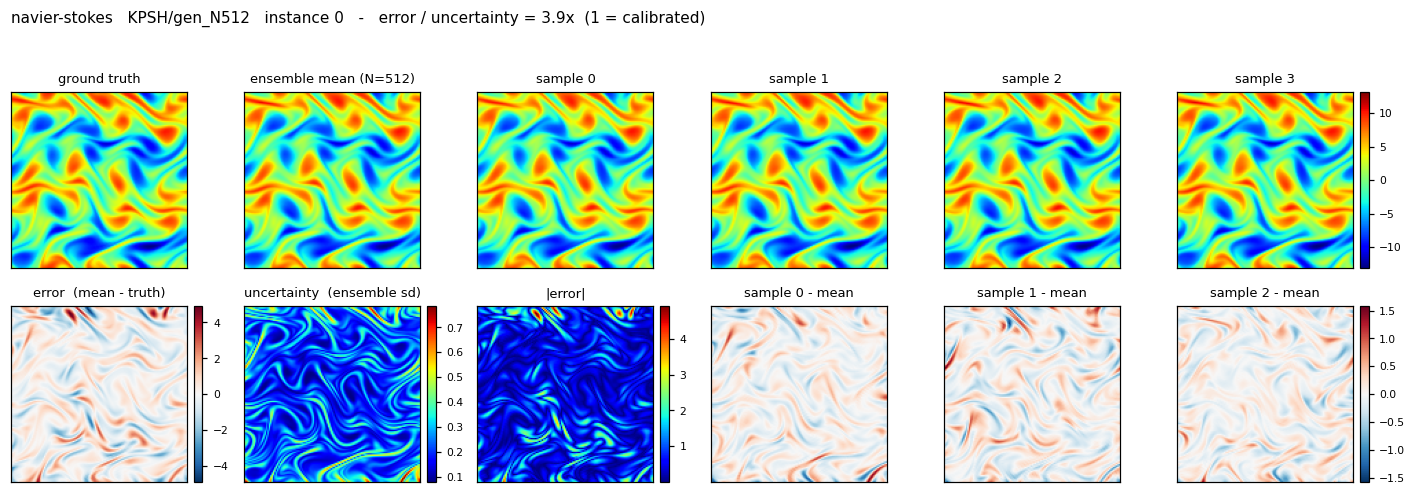

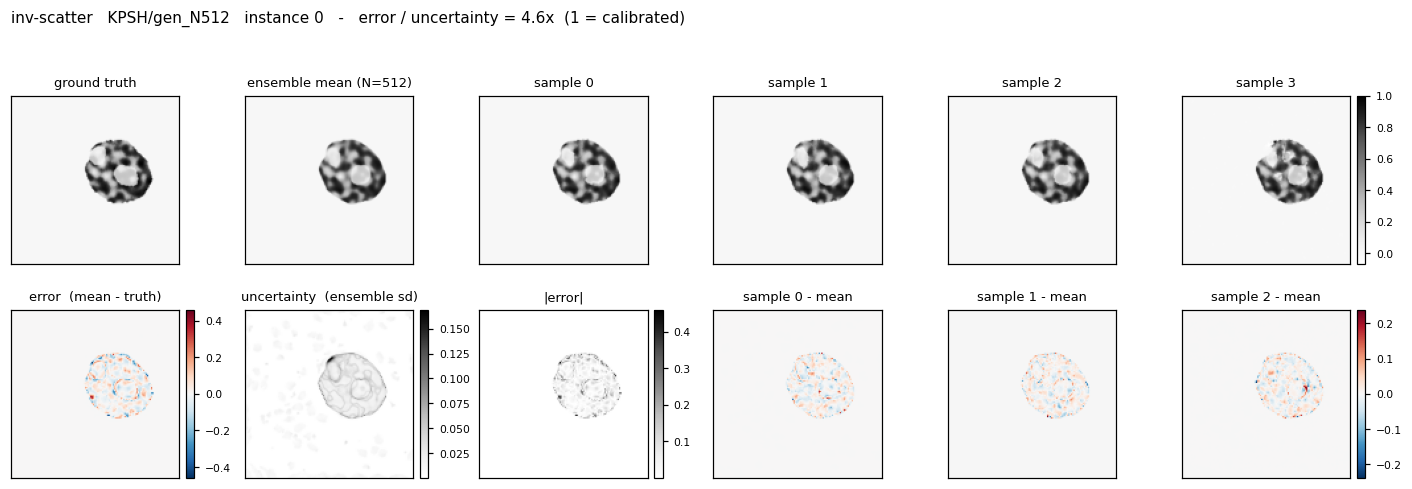

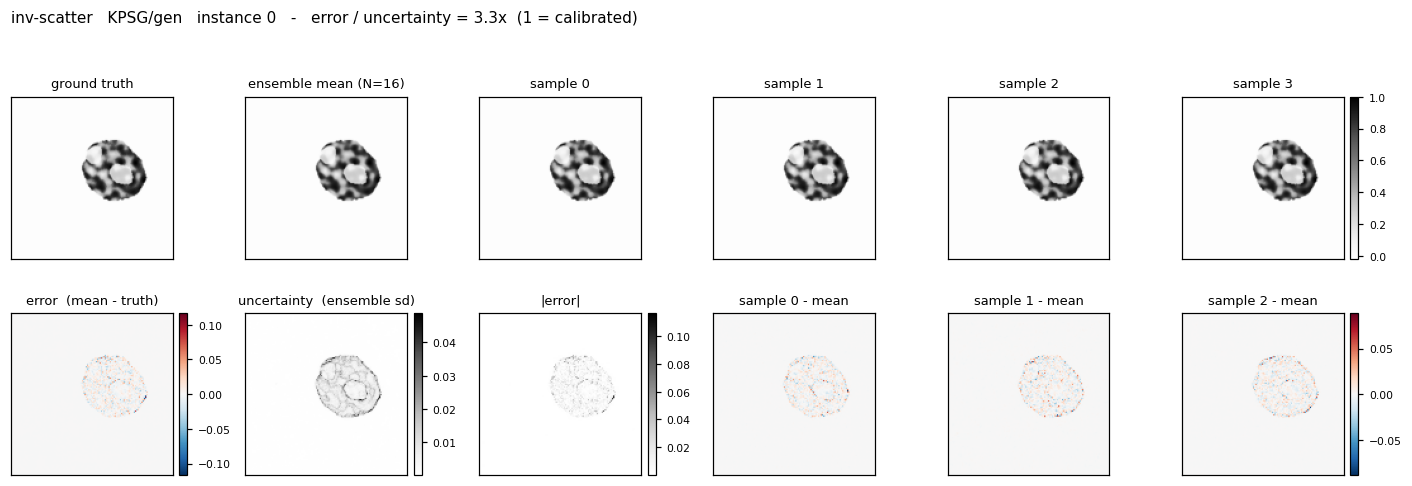

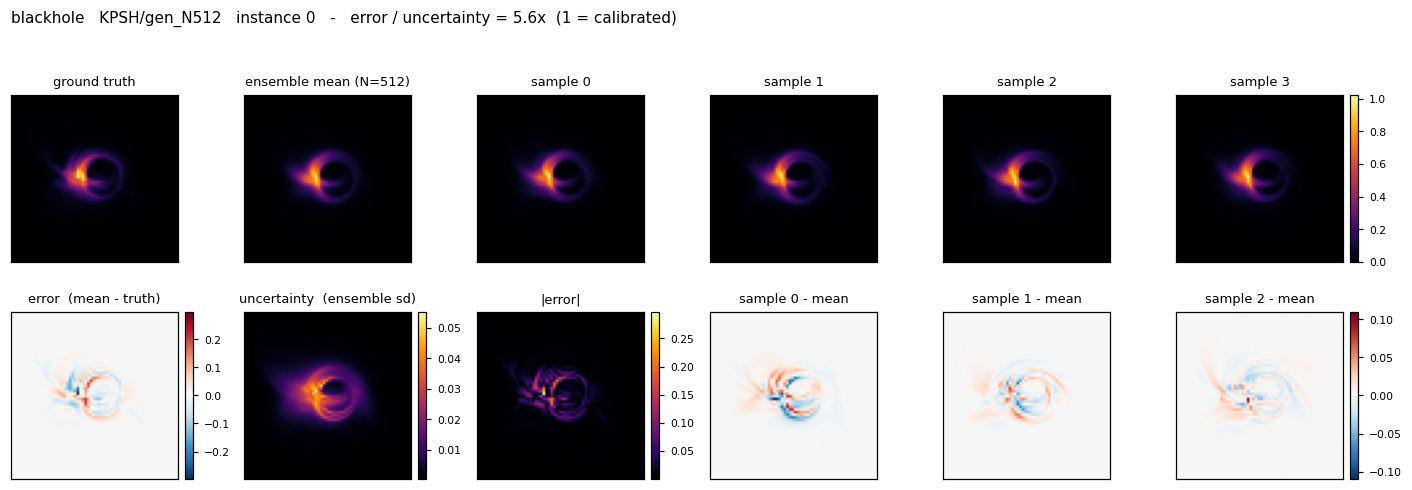

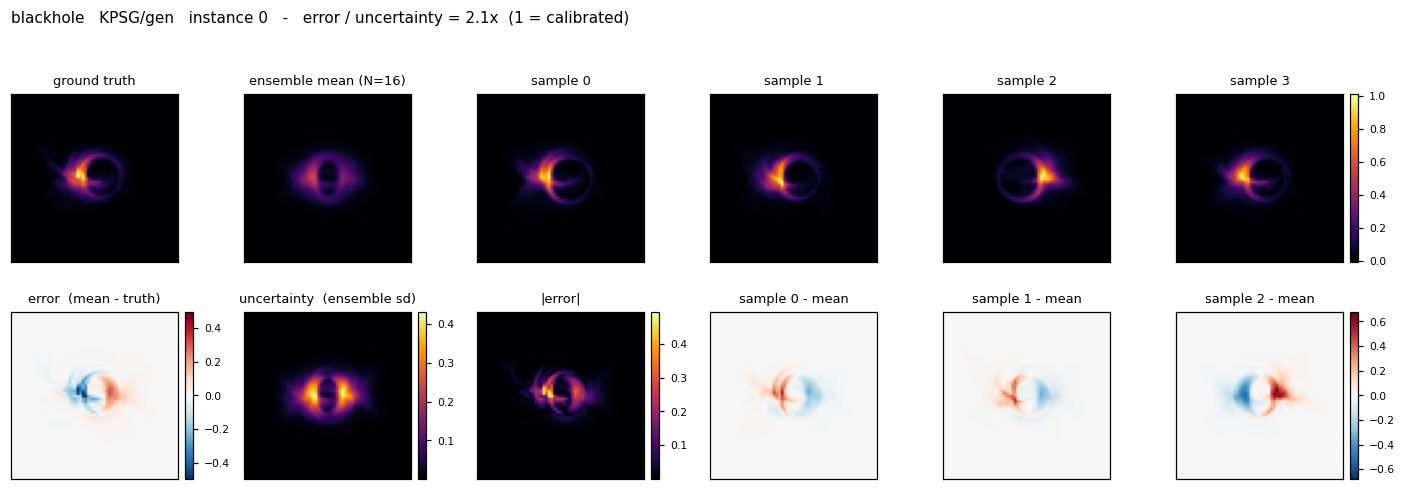

In [3]:
# What to show. One entry per (problem, algorithm, run, instance); edit freely.
# KPSG is included where it ran -- on inv-scatter it is the standout arm in the metrics, and
# seeing why is the point of a gallery.
PICKS = [
    ('navier-stokes', 'KPSH', 'gen_N512'),
    ('inv-scatter',   'KPSH', 'gen_N512'),
    ('inv-scatter',   'KPSG', 'gen'),
    ('blackhole',     'KPSH', 'gen_N512'),
    ('blackhole',     'KPSG', 'gen'),
]
IDS = (0, 1, 2)          # test instances to show for each pick
N_SHOW = 4               # individual samples per figure

for PROBLEM, ALGO, RUN in PICKS:
  if (PROBLEM, ALGO, RUN) not in RUNS:
    print(f'skipping {PROBLEM} {ALGO}/{RUN}: not on disk')
    continue
  for ID in IDS:

    x, t, d = load(PROBLEM, ALGO, RUN, ID)
    mean, std = x.mean(0), x.std(0)
    err = mean - t[0]

    # truth, mean and the individual samples are the SAME quantity -> one shared scale
    field = scale(torch.cat([t, x[:N_SHOW]]).numpy(), PROBLEM)

    fig, ax = plt.subplots(2, 2 + N_SHOW, figsize=(2.15 * (2 + N_SHOW), 4.7))
    panel(ax[0, 0], t[0], 'ground truth', cb=False, **field)
    panel(ax[0, 1], mean, f'ensemble mean (N={x.shape[0]})', cb=False, **field)
    for j in range(N_SHOW):
        panel(ax[0, 2 + j], x[j], f'sample {j}', cb=(j == N_SHOW - 1), **field)

    panel(ax[1, 0], err, 'error  (mean - truth)', **scale(err.numpy(), PROBLEM, 'error'))
    panel(ax[1, 1], std, 'uncertainty  (ensemble sd)', **scale(std.numpy(), PROBLEM, 'mag'))
    panel(ax[1, 2], err.abs(), '|error|', **scale(err.abs().numpy(), PROBLEM, 'mag'))
    dev = (x[:N_SHOW - 1] - mean).numpy()
    ds = scale(dev, PROBLEM, 'error')
    for j in range(N_SHOW - 1):
        panel(ax[1, 3 + j], dev[j], f'sample {j} - mean', cb=(j == N_SHOW - 2), **ds)

    ratio = float(err.pow(2).mean().sqrt() / std.mean())
    fig.suptitle(f'{PROBLEM}   {ALGO}/{RUN}   instance {ID}   -   '
                 f'error / uncertainty = {ratio:.1f}x  (1 = calibrated)',
                 x=0.01, ha='left', fontsize=10)
    plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

## 2. Methods side by side

Same instance, every method and ensemble size. Columns share a colour scale, so the
**uncertainty column is directly comparable across rows** — which is where the effect of N
shows up.

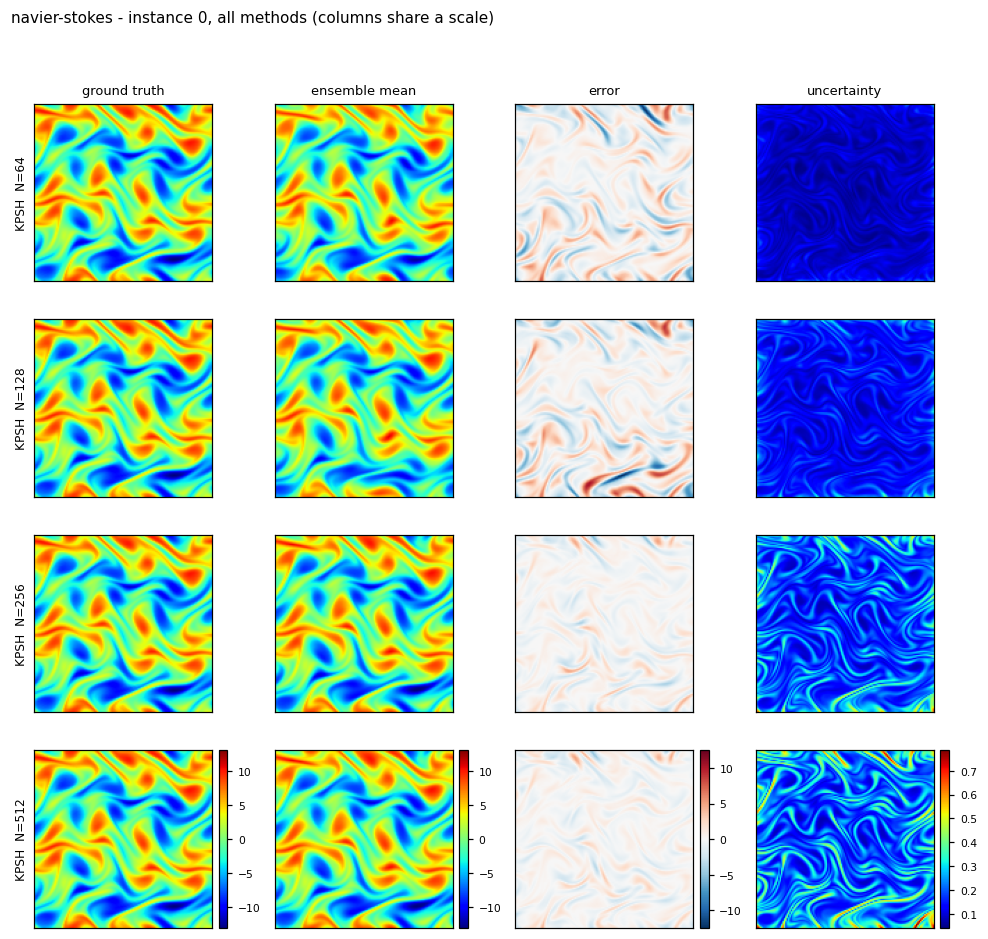

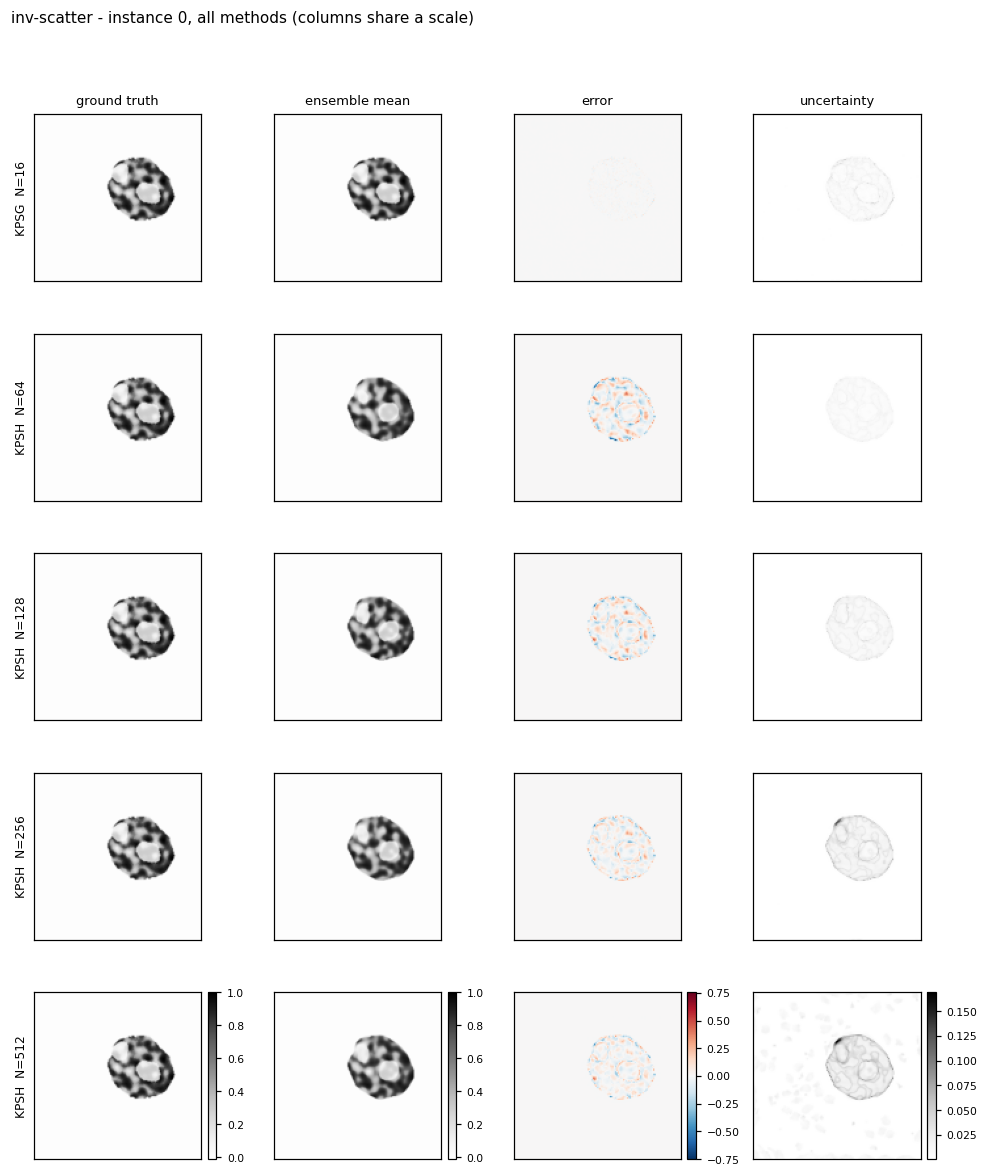

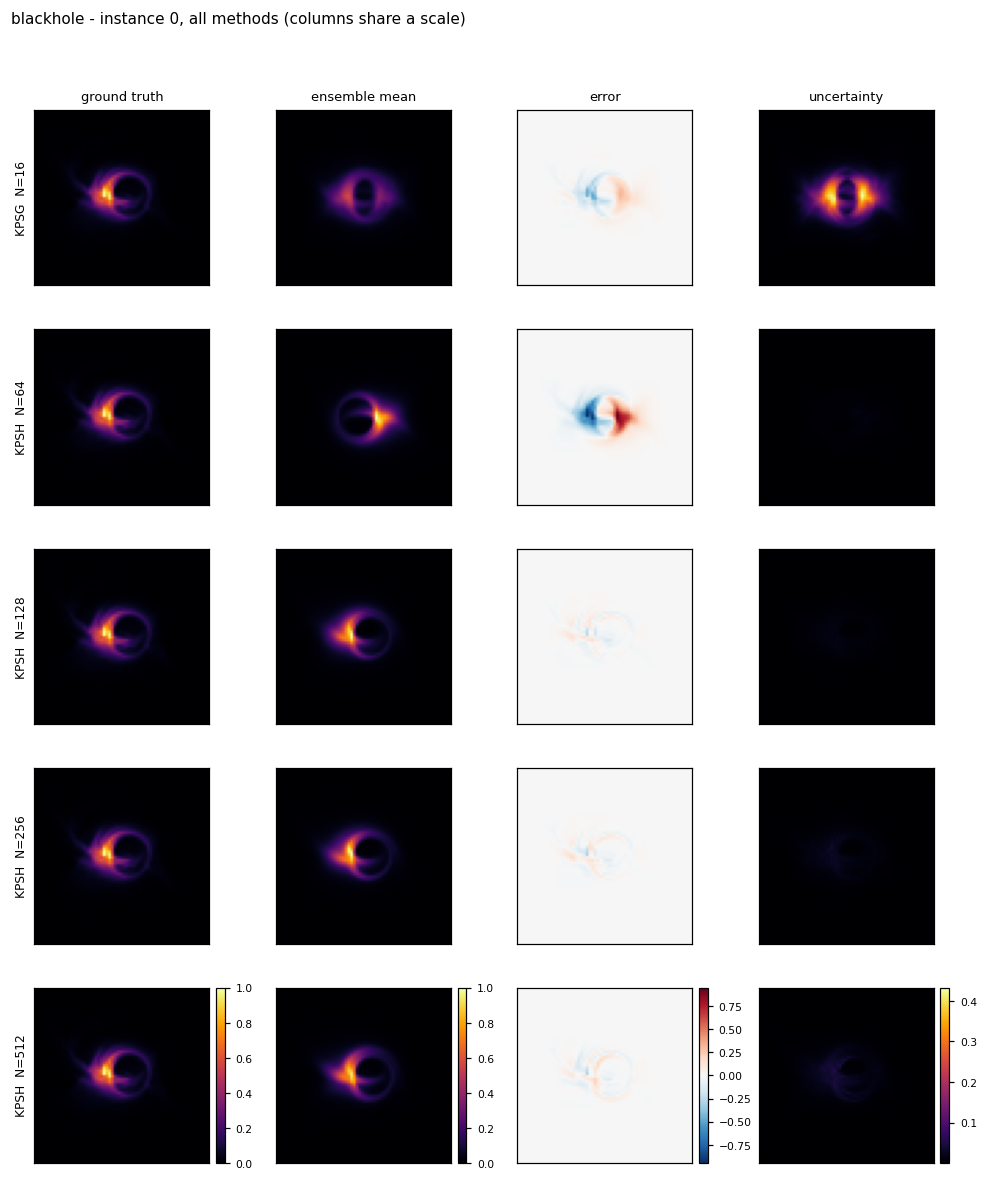

In [4]:
PROBLEMS = ('navier-stokes', 'inv-scatter', 'blackhole')     # <- edit
ID = 0

def nof(k):
    r"""Sort by ENSEMBLE SIZE, which is in the run name -- sorting by the number of ids put
    N=64 after N=512 and made the sweep unreadable."""
    tail = k[2].split('_N')[-1]
    return (k[1], int(tail) if tail.isdigit() else 0)

for PROBLEM in PROBLEMS:
    keys = sorted([k for k in RUNS if k[0] == PROBLEM and ID < len(RUNS[k])], key=nof)
    if not keys:
        continue

    rows = []
    for k in keys:
        xx, tt, _ = load(*k, ID)
        rows.append((f'{k[1]}  N={xx.shape[0]}', xx.mean(0), xx.mean(0) - tt[0], xx.std(0)))
    truth = load(*keys[0], ID)[1][0]

    field = scale(torch.stack([truth] + [r[1] for r in rows]).numpy(), PROBLEM)
    esc = scale(np.stack([r[2].numpy() for r in rows]), PROBLEM, 'error')
    ssc = scale(np.stack([r[3].numpy() for r in rows]), PROBLEM, 'mag')

    fig, ax = plt.subplots(len(rows), 4, figsize=(9.0, 2.2 * len(rows)), squeeze=False)
    for i, (lab, m, e, s) in enumerate(rows):
        last = i == len(rows) - 1        # one colourbar per column, on the bottom row
        panel(ax[i, 0], truth, 'ground truth' if i == 0 else '', cb=last, **field)
        panel(ax[i, 1], m, 'ensemble mean' if i == 0 else '', cb=last, **field)
        panel(ax[i, 2], e, 'error' if i == 0 else '', cb=last, **esc)
        panel(ax[i, 3], s, 'uncertainty' if i == 0 else '', cb=last, **ssc)
        ax[i, 0].set_ylabel(lab, fontsize=8)
    fig.suptitle(f'{PROBLEM} - instance {ID}, all methods (columns share a scale)',
                 x=0.01, ha='left', fontsize=10)
    plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

## 3. Several instances

One row per test instance, to check that whatever the first view showed is typical rather
than a lucky or unlucky draw.

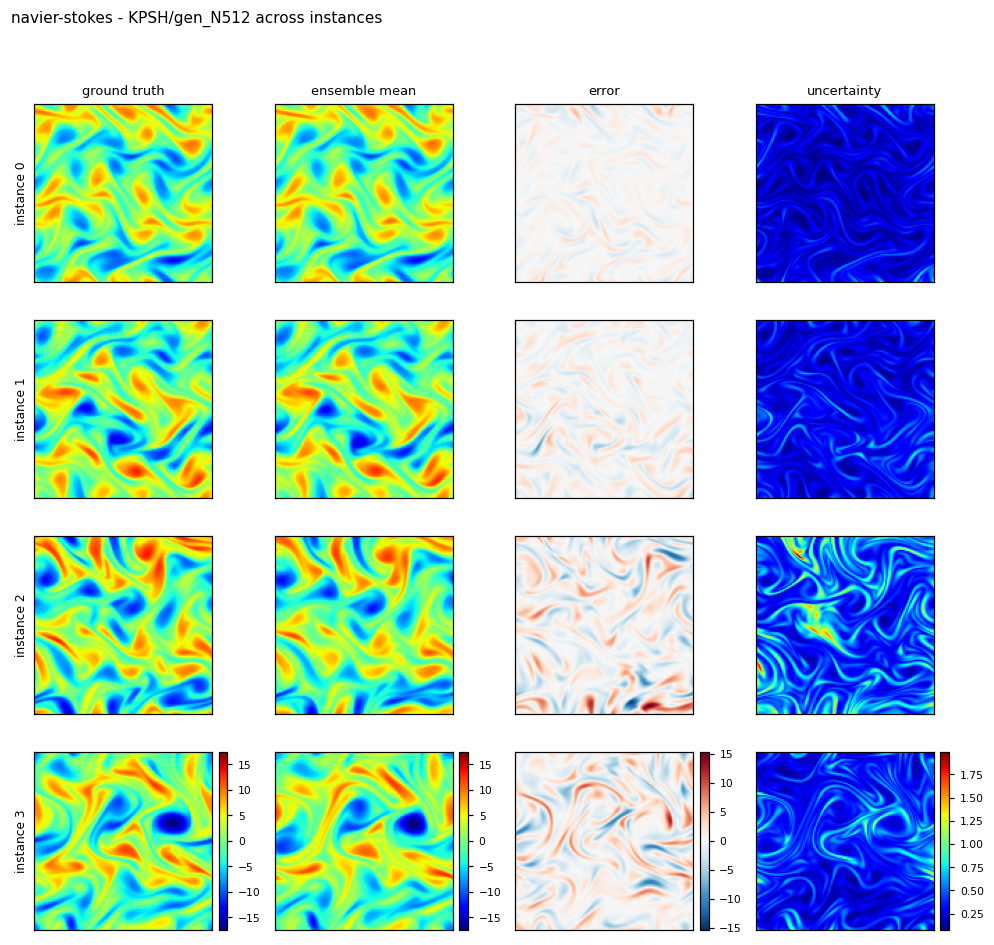

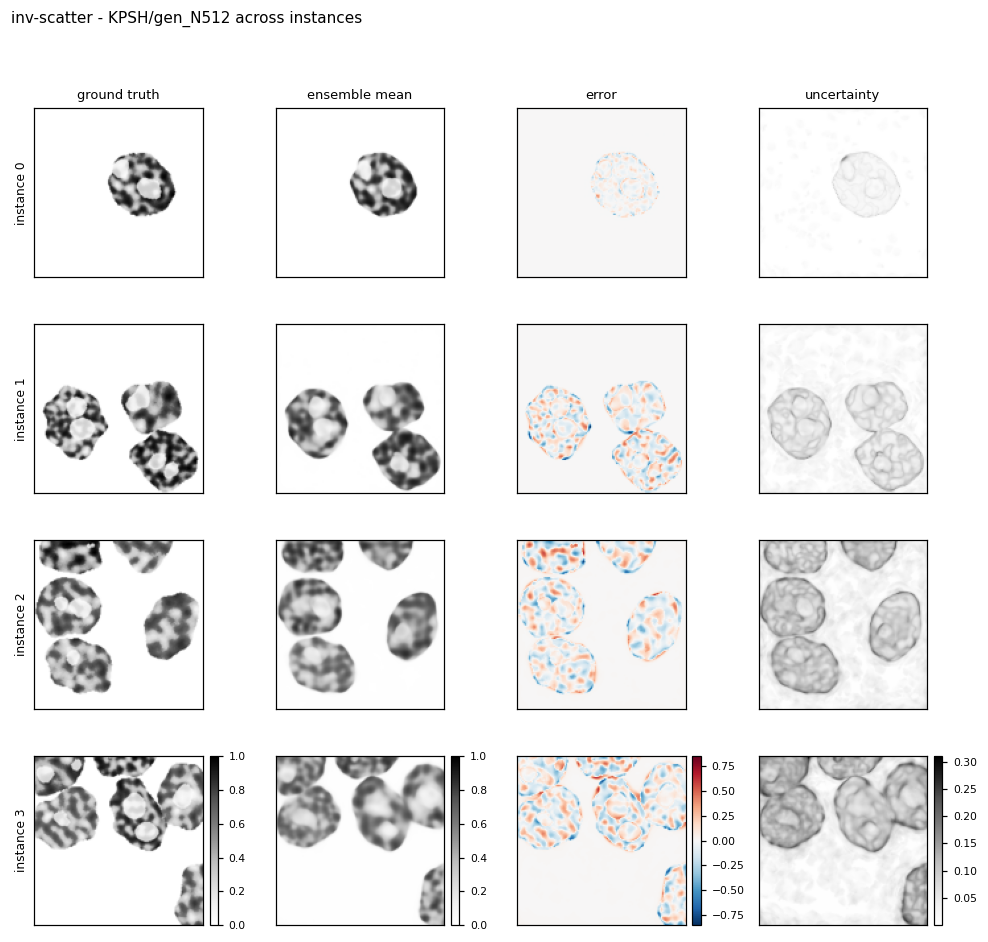

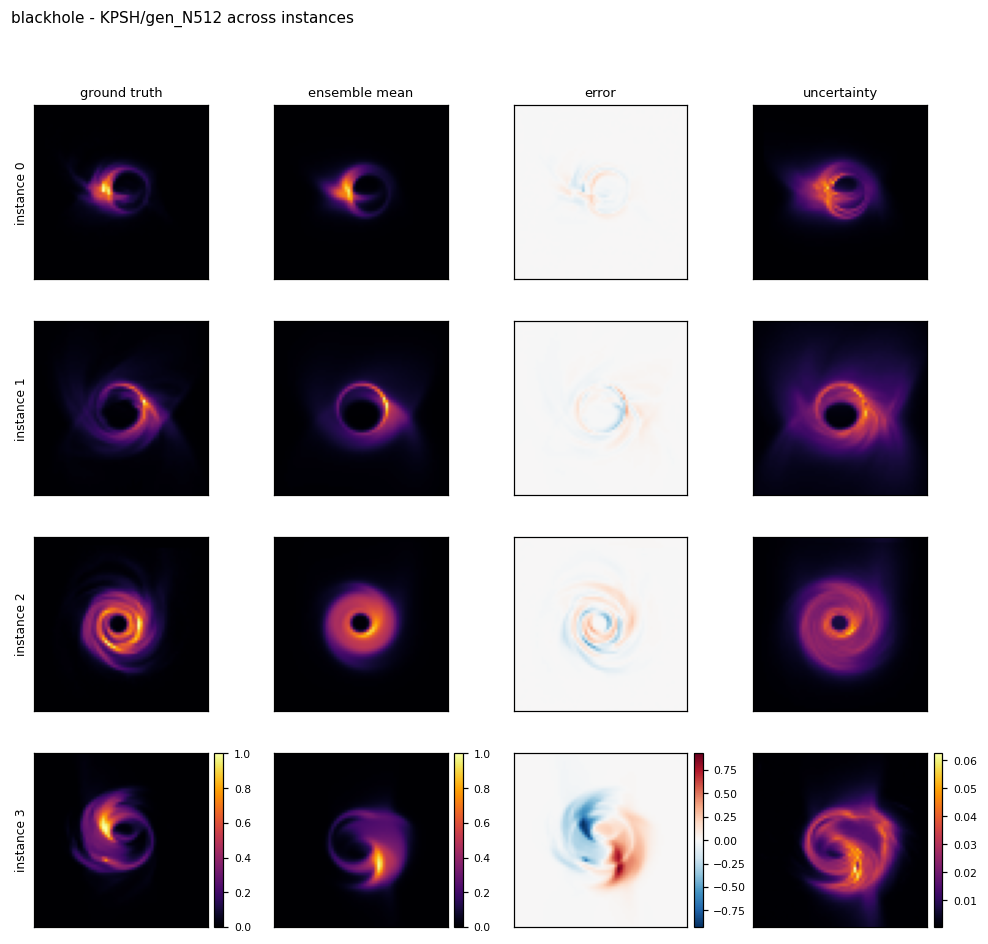

In [5]:
SPREADS = [('navier-stokes', 'KPSH', 'gen_N512'),             # <- edit
           ('inv-scatter', 'KPSH', 'gen_N512'),
           ('blackhole', 'KPSH', 'gen_N512')]
IDS = range(4)

for PROBLEM, ALGO, RUN in SPREADS:
    if (PROBLEM, ALGO, RUN) not in RUNS:
        continue
    data = [load(PROBLEM, ALGO, RUN, i) for i in IDS]
    field = scale(torch.cat([t for _, t, _ in data]).numpy(), PROBLEM)
    esc = scale(np.stack([(x.mean(0) - t[0]).numpy() for x, t, _ in data]),
            PROBLEM, 'error')
    ssc = scale(np.stack([x.std(0).numpy() for x, _, _ in data]), PROBLEM, 'mag')

    fig, ax = plt.subplots(len(data), 4, figsize=(9.0, 2.2 * len(data)), squeeze=False)
    for i, (x, t, _) in enumerate(data):
        last = i == len(data) - 1
        panel(ax[i, 0], t[0], 'ground truth' if i == 0 else '', cb=last, **field)
        panel(ax[i, 1], x.mean(0), 'ensemble mean' if i == 0 else '', cb=last, **field)
        panel(ax[i, 2], x.mean(0) - t[0], 'error' if i == 0 else '', cb=last, **esc)
        panel(ax[i, 3], x.std(0), 'uncertainty' if i == 0 else '', cb=last, **ssc)
        ax[i, 0].set_ylabel(f'instance {list(IDS)[i]}', fontsize=8)
    fig.suptitle(f'{PROBLEM} - {ALGO}/{RUN} across instances', x=0.01, ha='left', fontsize=10)
    plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

## 4. Observation space

Does the reconstruction reproduce the data that was actually measured? This is the
well-posed question — many states can explain one observation, so a large error in x with a
small residual in y means the problem is under-determined, not that the method failed.

Only shown where the observation is image-like: a downsampled field for navier-stokes, and
the complex scattered field (20 transmitters x 360 receivers, shown as magnitude) for
inv-scatter. Blackhole's observation is a packed vector of amplitudes, closure phases and
their error bars, so there is nothing to look at.

**The residual has a floor**: `recon_obs` is the operator applied *with* its observation
noise, so even a perfect reconstruction differs from `observation` by one noise draw.

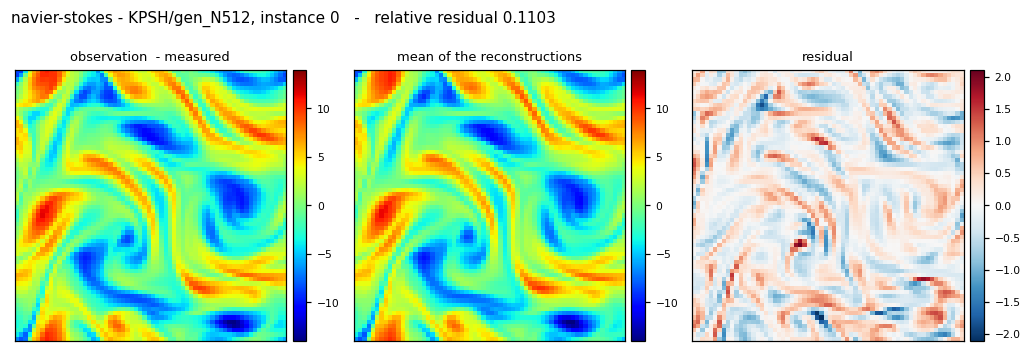

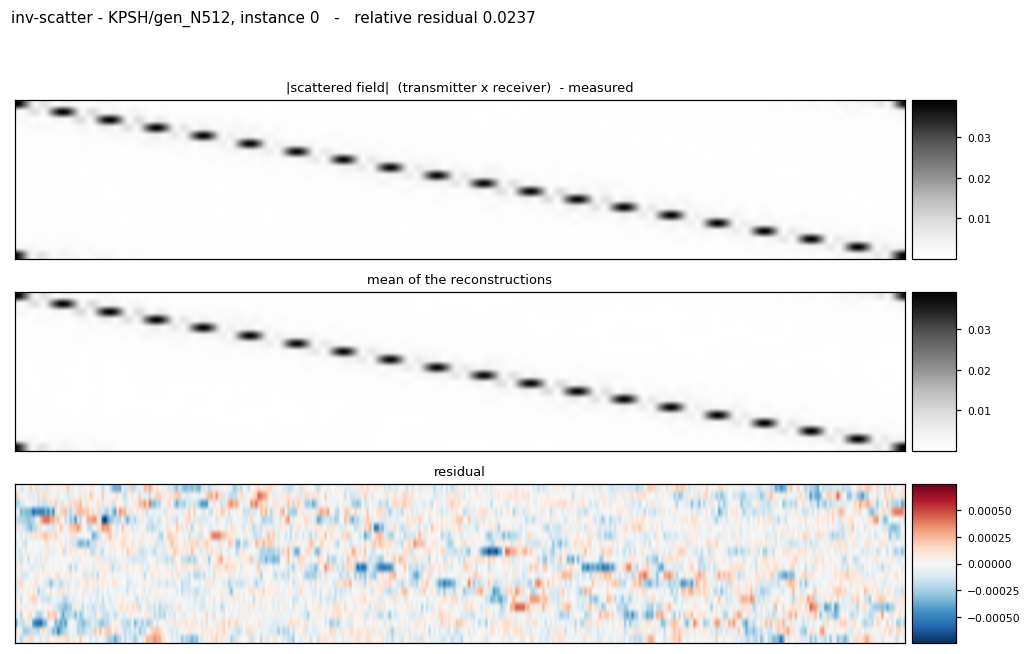

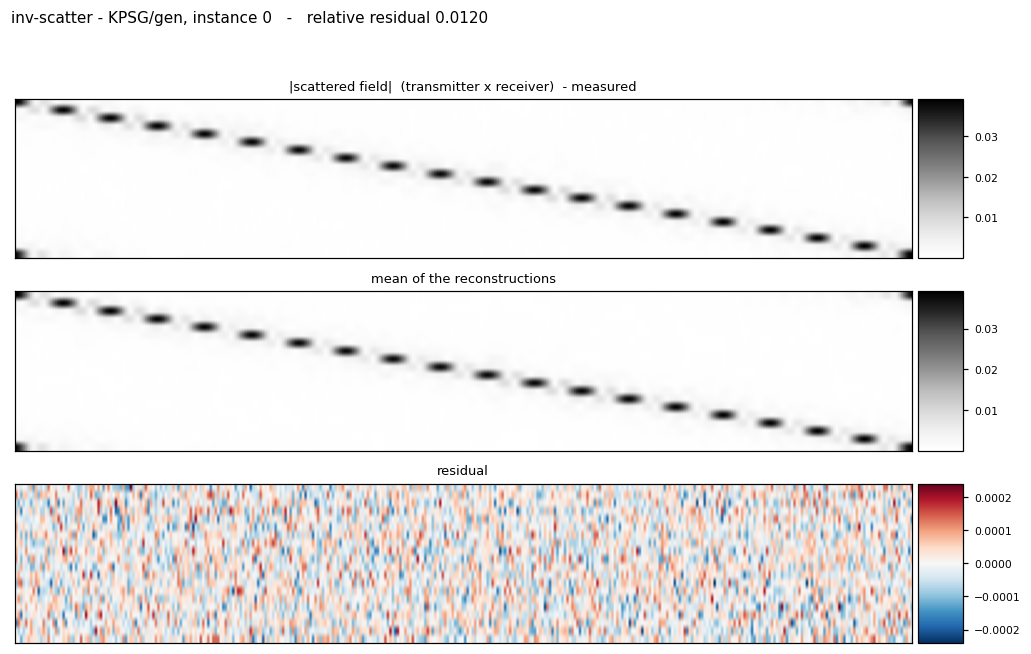

blackhole: the observation is a packed vector of shape (1, 1, 4007, 1) (amplitudes, closure phases and their error bars) - not an image, nothing to show.
blackhole: the observation is a packed vector of shape (1, 1, 4007, 1) (amplitudes, closure phases and their error bars) - not an image, nothing to show.


In [6]:
ID = IDS[0]                      # one instance is enough here

for PROBLEM, ALGO, RUN in PICKS:
    if (PROBLEM, ALGO, RUN) not in RUNS:
        continue
    _, _, d = load(PROBLEM, ALGO, RUN, ID)
    obs, ro = d['observation'].cpu(), d['recon_obs'].cpu()

    if torch.is_complex(obs):
        obs, ro, what = obs.abs(), ro.abs(), '|scattered field|  (transmitter x receiver)'
    else:
        what = 'observation'
    obs, ro = obs.float(), ro.float()

    if obs.squeeze().ndim != 2:
        print(f'{PROBLEM}: the observation is a packed vector of shape {tuple(obs.shape)} '
              f'(amplitudes, closure phases and their error bars) - not an image, nothing '
              f'to show.')
        continue

    o2, m2 = obs.squeeze(), ro.mean(0).squeeze()
    res = m2 - o2
    sc = scale(torch.stack([o2, m2]).numpy(), PROBLEM)
    wide = o2.shape[-1] > 3 * o2.shape[-2]          # inv-scatter is 20 x 360
    fig, ax = plt.subplots(3 if wide else 1, 3 if not wide else 1,
                           figsize=(9.4, 6.0) if wide else (9.4, 3.2), squeeze=False)
    ax = ax.ravel()
    panel(ax[0], o2, f'{what}  - measured', **sc)
    panel(ax[1], m2, 'mean of the reconstructions', **sc)
    panel(ax[2], res, 'residual', **scale(res.numpy(), PROBLEM, 'error'))
    for a in ax:
        a.set_aspect('auto' if wide else 'equal')
    fig.suptitle(f'{PROBLEM} - {ALGO}/{RUN}, instance {ID}   -   relative residual '
                 f'{float(res.norm() / o2.norm()):.4f}', x=0.01, ha='left', fontsize=10)
    plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()